In [6]:
import pandas as pd

#load the data
df = pd.read_csv(r"E:\supply-chain-analysis\data\raw_data\retail_store_inventory.csv")

print(df.isnull().sum())

print(df.head)


Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64
<bound method NDFrame.head of              Date Store ID Product ID     Category Region  Inventory Level  \
0      2022-01-01     S001      P0001    Groceries  North              231   
1      2022-01-01     S001      P0002         Toys  South              204   
2      2022-01-01     S001      P0003         Toys   West              102   
3      2022-01-01     S001      P0004         Toys  North              469   
4      2022-01-01     S001      P0005  Electronics   East              166   
...           ...      ...        ...          ...    ...              ...   
73095  2024-01-01     S005      P0016    Furniture 

In [7]:
print(df.info())    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [8]:
print(df.describe())

       Inventory Level    Units Sold  Units Ordered  Demand Forecast  \
count     73100.000000  73100.000000   73100.000000     73100.000000   
mean        274.469877    136.464870     110.004473       141.494720   
std         129.949514    108.919406      52.277448       109.254076   
min          50.000000      0.000000      20.000000        -9.990000   
25%         162.000000     49.000000      65.000000        53.670000   
50%         273.000000    107.000000     110.000000       113.015000   
75%         387.000000    203.000000     155.000000       208.052500   
max         500.000000    499.000000     200.000000       518.550000   

              Price      Discount  Holiday/Promotion  Competitor Pricing  
count  73100.000000  73100.000000       73100.000000        73100.000000  
mean      55.135108     10.009508           0.497305           55.146077  
std       26.021945      7.083746           0.499996           26.191408  
min       10.000000      0.000000           0.00000

In [10]:
# 1. Convert Date to a proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extract Month and Day of Week (To find 'Peak' shopping times)
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.day_name()

# 3. Calculate "Inventory Turnover" (How fast are you selling?)
# Formula: Units Sold / Current Stock
df['Inventory_Turnover'] = df['Units Sold'] / df['Inventory Level']

# 4. Create a "Stock Status" Label
def check_stock(row):
    if row['Inventory Level'] < 20: # Example threshold
        return 'Critical'
    elif row['Inventory Level'] < 50:
        return 'Low'
    else:
        return 'Healthy'

df['Stock_Status'] = df.apply(check_stock, axis=1)

print(df[['Date', 'Inventory_Turnover', 'Stock_Status']].head())

        Date  Inventory_Turnover Stock_Status
0 2022-01-01            0.549784      Healthy
1 2022-01-01            0.735294      Healthy
2 2022-01-01            0.637255      Healthy
3 2022-01-01            0.130064      Healthy
4 2022-01-01            0.084337      Healthy


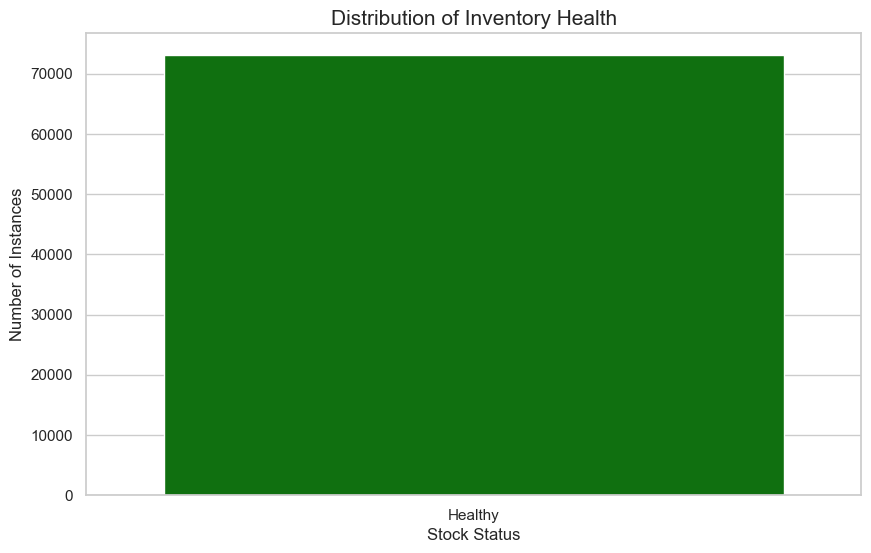

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a bar chart of Stock Status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Stock_Status', palette={'Healthy': 'green', 'Low': 'orange', 'Critical': 'red'})

plt.title('Distribution of Inventory Health', fontsize=15)
plt.xlabel('Stock Status', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)

# Save the plot for your GitHub README later
plt.savefig('../dashboard/inventory_health_chart.png')
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Prepare data for a simple trend line
# We'll use 'Days' as our X and 'Units_Sold' as our Y
df['Day_Index'] = np.arange(len(df))
X = df[['Day_Index']]
y = df['Units Sold']

# 2. Train the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict the next 7 days
next_days = np.array([[i] for i in range(len(df), len(df) + 7)])
predictions = model.predict(next_days)

print("Predicted units to be sold over the next 7 days:")
print(predictions)

Predicted units to be sold over the next 7 days:
[136.07167971 136.07166896 136.0716582  136.07164744 136.07163668
 136.07162593 136.07161517]


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
# Calculate Average Daily Sales
avg_daily_sales = df['Units Sold'].mean()

# Lead Time (Average days to get new stock - assuming 5 days for this project)
lead_time = 5 

# Safety Stock Formula = Avg Daily Sales * Lead Time
# This is a standard industry KPI
df['Safety_Stock_Needed'] = avg_daily_sales * lead_time

# Identify if current stock is below safety level
df['Reorder_Point_Alert'] = df['Inventory Level'] < df['Safety_Stock_Needed']

print(f"Safety Stock Level Recommended: {round(avg_daily_sales * lead_time, 2)} units")
print(df[df['Reorder_Point_Alert'] == True][['Date', 'Inventory Level', 'Safety_Stock_Needed']].head())

Safety Stock Level Recommended: 682.32 units
        Date  Inventory Level  Safety_Stock_Needed
0 2022-01-01              231            682.32435
1 2022-01-01              204            682.32435
2 2022-01-01              102            682.32435
3 2022-01-01              469            682.32435
4 2022-01-01              166            682.32435
